In [1]:
!pip install -q --upgrade pip
!pip install -q numpy scipy matplotlib torch torchvision
!pip install -q git+https://github.com/sandialabs/cross-sim.git

print("✅ Done! Restart Runtime now.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompat

In [2]:
# Core scientific stack
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# CrossSim
from simulator import AnalogCore, CrossSimParameters

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print("=" * 60)
print("✅ All libraries imported successfully!")
print("=" * 60)
print(f"PyTorch version   : {torch.__version__}")
print(f"Device            : {device}")
if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")
print("=" * 60)

✅ All libraries imported successfully!
PyTorch version   : 2.10.0+cu128
Device            : cuda
GPU               : Tesla T4


In [3]:
# ============================================================================
# AIMC Simulation Configuration
# ============================================================================

# Model & Dataset
MODEL_NAME = "inception_v3"
DATASET_NAME = "CIFAR-10"
INPUT_SIZE = 299  # InceptionV3 requires 299x299 input
NUM_CLASSES = 10
BATCH_SIZE = 64

# Evaluation size (subset for faster experiments)
EVAL_SIZE = 5000  # Use first 5000 CIFAR-10 test images

# Sweep parameters
ADC_BITS_LIST = [2, 4, 6, 8]
DAC_BITS_LIST = [2, 4, 6, 8]
WEIGHT_BITS = 8  # Fixed

# Drift times in days
DRIFT_TIMES = [0, 1, 3, 7, 14, 30]

# Device models
DEVICE_MODELS = ["IdealDevice", "NormalIndependentDevice", "NormalProportionalDevice", "RRAMMilo"]

print("=" * 60)
print("AIMC Configuration")
print("=" * 60)
print(f"Model             : {MODEL_NAME}")
print(f"Dataset           : {DATASET_NAME}")
print(f"Input Size        : {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Evaluation Size   : {EVAL_SIZE}")
print(f"ADC Bits          : {ADC_BITS_LIST}")
print(f"DAC Bits          : {DAC_BITS_LIST}")
print(f"Drift Times       : {DRIFT_TIMES}")
print(f"Device Models     : {DEVICE_MODELS}")
print("=" * 60)

AIMC Configuration
Model             : inception_v3
Dataset           : CIFAR-10
Input Size        : 299x299
Evaluation Size   : 5000
ADC Bits          : [2, 4, 6, 8]
DAC Bits          : [2, 4, 6, 8]
Drift Times       : [0, 1, 3, 7, 14, 30]
Device Models     : ['IdealDevice', 'NormalIndependentDevice', 'NormalProportionalDevice', 'RRAMMilo']


In [4]:

def inference_clean(model, dataloader, device='cpu'):
    """
    Run clean inference without any quantization, noise, or device imperfections.
    
    This serves as the baseline for comparing accuracy degradation.
    
    Args:
        model: PyTorch model
        dataloader: DataLoader for evaluation
        device: torch device
    
    Returns:
        accuracy: Top-1 accuracy (0-100)
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = (correct / total) * 100
    return accuracy



In [5]:
def load_cifar10_dataloader(input_size=299, batch_size=64, eval_size=5000):
    """
    Load CIFAR-10 test set with proper normalization for InceptionV3.
    
    Args:
        input_size: Target input resolution (usually 299 for InceptionV3)
        batch_size: Batch size for DataLoader
        eval_size: Number of test samples to use
    
    Returns:
        DataLoader: Test dataloader
    """
    transform = transforms.Compose([
        transforms.Resize(input_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2023, 0.1994, 0.2010]
        )
    ])
    
    dataset = datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )
    
    # Subset for faster experiments
    if eval_size < len(dataset):
        dataset = Subset(dataset, range(eval_size))
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return dataloader


# Load CIFAR-10
dataloader = load_cifar10_dataloader(
    input_size=INPUT_SIZE,
    batch_size=BATCH_SIZE,
    eval_size=EVAL_SIZE
)

print("=" * 60)
print("✅ CIFAR-10 Loaded")
print("=" * 60)
print(f"Total Batches     : {len(dataloader)}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Total Samples     : {EVAL_SIZE}")
print("=" * 60)

100%|██████████| 170M/170M [00:01<00:00, 95.9MB/s] 


✅ CIFAR-10 Loaded
Total Batches     : 79
Batch Size        : 64
Total Samples     : 5000


In [6]:
def build_inception_v3(num_classes=10, device='cpu'):
    """
    Build InceptionV3 pretrained on ImageNet, modified for CIFAR-10 (10 classes).
    
    Args:
        num_classes: Number of output classes
        device: torch device (cuda or cpu)
    
    Returns:
        model: Modified InceptionV3 in eval mode
    """
    # Load pretrained InceptionV3
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        aux_logits=True  # Must be True for pretrained compatibility
    )
    
    # Disable auxiliary classifier during inference
    model.aux_logits = False
    
    # Replace final FC layer for 10-class classification
    model.fc = nn.Linear(2048, num_classes)
    
    # Move to device and set to eval mode
    model = model.to(device)
    model.eval()
    
    return model


# Build model
model = build_inception_v3(num_classes=NUM_CLASSES, device=device)

print("=" * 60)
print("✅ InceptionV3 Model Ready")
print("=" * 60)
print(f"Input Size        : 299x299x3")
print(f"Output Classes    : {NUM_CLASSES}")
print(f"Device            : {device}")
print(f"FC Layer Shape    : {model.fc.weight.shape}")
print("=" * 60)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters  : {total_params:,}")
print(f"Trainable Params  : {trainable_params:,}")
print("=" * 60)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 218MB/s] 


✅ InceptionV3 Model Ready
Input Size        : 299x299x3
Output Classes    : 10
Device            : cuda
FC Layer Shape    : torch.Size([10, 2048])
Total Parameters  : 25,132,754
Trainable Params  : 25,132,754


In [7]:
def make_params(
    adc_bits=8,
    dac_bits=8,
    weight_bits=8,
    error_model="IdealDevice",
    noise_model="IdealDevice",
    drift_model="IdealDevice",
    t_drift=0,
    Nslices=1,
    NrowsMax=1152,
    Rmin=1e3,
    Rmax=1e6,
    style="BALANCED"
):
    """
    Configure CrossSim RRAM crossbar parameters.
    
    All hardware imperfections (DAC quantization, ADC quantization,
    programming error, read noise, and conductance drift) are handled
    internally by CrossSim or our simulation layer.
    
    Device Models:
        - IdealDevice:              No imperfections
        - NormalIndependentDevice:  Gaussian noise, fixed std
        - NormalProportionalDevice: Gaussian noise, proportional to conductance
        - RRAMMilo:                 Real RRAM behavior (includes drift)
    
    Args:
        adc_bits: ADC resolution [2, 4, 6, 8]
        dac_bits: DAC resolution [2, 4, 6, 8]
        weight_bits: Weight cell resolution (fixed at 8 for this work)
        error_model: Programming error model
        noise_model: Read noise model
        drift_model: Conductance drift model
        t_drift: Drift time in days [0, 1, 3, 7, 14, 30]
        Nslices: Number of weight slices
        NrowsMax: Max rows per crossbar
        Rmin: ON state resistance (Ohms)
        Rmax: OFF state resistance (Ohms)
        style: Crossbar style (BALANCED or OFFSET)
    
    Returns:
        params: Configured parameter object with device models
    """
    p = CrossSimParameters()
    
    # Core architecture
    p.core.style = style
    p.core.mapping.inputs.mvm.min = 0
    p.core.mapping.inputs.mvm.max = 1
    p.core.mapping.weights.percentile = 100
    
    # Crossbar dimensions
    p.xbar.array.NrowsMax = NrowsMax
    p.xbar.Nslices = Nslices
    
    # Device properties
    p.xbar.device.Rmin = Rmin
    p.xbar.device.Rmax = Rmax
    p.xbar.device.cell_bits = weight_bits
    
    # ADC Configuration
    p.xbar.adc.bits = adc_bits
    p.xbar.adc.adc_type = "generic"
    p.xbar.adc.range_option = "MAX"
    
    # DAC Configuration
    p.xbar.dac.bits = dac_bits
    
    # Device Imperfections (now properly tracked)
    p.xbar.device.programming_error.model = error_model
    p.xbar.device.read_noise.model = noise_model
    p.xbar.device.drift_error.model = drift_model
    p.xbar.device.time = t_drift
    
    # Store model names for simulation layer (NEW!)
    p.error_model = error_model
    p.noise_model = noise_model
    p.drift_model = drift_model
    p.t_drift = t_drift
    
    return p


print("=" * 60)
print("✅ Enhanced CrossSim Parameter Builder Ready")
print("=" * 60)
print("Valid Device Models:")
print("  - IdealDevice              (no imperfections)")
print("  - NormalIndependentDevice  (fixed Gaussian noise)")
print("  - NormalProportionalDevice (prop. Gaussian noise)")
print("  - RRAMMilo                 (realistic RRAM)")
print("=" * 60)


✅ Enhanced CrossSim Parameter Builder Ready
Valid Device Models:
  - IdealDevice              (no imperfections)
  - NormalIndependentDevice  (fixed Gaussian noise)
  - NormalProportionalDevice (prop. Gaussian noise)
  - RRAMMilo                 (realistic RRAM)


In [8]:

def inference_clean(model, dataloader, device='cpu'):
    """
    Run clean inference without any quantization, noise, or device imperfections.
    
    This serves as the baseline for comparing accuracy degradation.
    
    Args:
        model: PyTorch model
        dataloader: DataLoader for evaluation
        device: torch device
    
    Returns:
        accuracy: Top-1 accuracy (0-100)
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = (correct / total) * 100
    return accuracy



In [9]:
def quantize_tensor(x, bits):
    """Simulate low-bit quantization."""
    if bits >= 32:
        return x
    levels = 2 ** bits
    x_min, x_max = x.min(), x.max()
    x_norm = (x - x_min) / (x_max - x_min + 1e-8)
    x_quant = torch.round(x_norm * (levels - 1)) / (levels - 1)
    x_dequant = x_quant * (x_max - x_min) + x_min
    return x_dequant


def add_device_noise(tensor, device_model, magnitude=0.02):
    """
    Add device-specific noise based on selected model.
    
    Args:
        tensor: Input tensor to add noise to
        device_model: Device model name (IdealDevice, NormalIndependent, NormalProportional, RRAMMilo)
        magnitude: Noise magnitude parameter
    
    Returns:
        tensor with noise added
    """
    if device_model == "IdealDevice":
        return tensor
    
    elif device_model == "NormalIndependentDevice":
        # Fixed Gaussian noise (std = magnitude)
        noise = torch.randn_like(tensor) * magnitude
        return tensor + noise
    
    elif device_model == "NormalProportionalDevice":
        # Noise proportional to signal magnitude
        noise = torch.randn_like(tensor) * (magnitude * torch.abs(tensor))
        return tensor + noise
    
    elif device_model == "RRAMMilo":
        # RRAM-specific: higher noise, with clipping effects
        noise = torch.randn_like(tensor) * (magnitude * 1.5)
        noisy = tensor + noise
        # RRAM clips at extremes
        return torch.clamp(noisy, tensor.min(), tensor.max())
    
    else:
        return tensor


def add_drift_noise(tensor, drift_days, base_magnitude=0.01):
    """
    Add noise that increases with drift time.
    
    Conductance drift in RRAM follows diffusion: σ_drift ~ sqrt(time)
    
    Args:
        tensor: Input tensor
        drift_days: Number of days of drift
        base_magnitude: Base noise magnitude per sqrt(day)
    
    Returns:
        tensor with drift-induced noise
    """
    if drift_days <= 0:
        return tensor
    
    # Drift increases with sqrt(time) - typical for diffusion processes
    drift_noise_magnitude = base_magnitude * np.sqrt(drift_days)
    drift_noise = torch.randn_like(tensor) * drift_noise_magnitude
    
    return tensor + drift_noise


def inference_quantized(model, dataloader, adc_bits=8, dac_bits=8, device='cpu', 
                        device_model="IdealDevice", drift_days=0):
    """
    Run inference with DAC/ADC quantization + device imperfections.
    
    Args:
        model: PyTorch model
        dataloader: DataLoader for evaluation
        adc_bits: ADC resolution (output quantization)
        dac_bits: DAC resolution (input quantization)
        device: torch device
        device_model: Device imperfection model
        drift_days: Conductance drift time in days
    
    Returns:
        accuracy: Top-1 accuracy (0-100)
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            # DAC quantization: input precision
            images_quantized = quantize_tensor(images, dac_bits)
            
            # Add DAC device noise
            images_with_noise = add_device_noise(images_quantized, device_model, magnitude=0.01)
            
            # Forward pass
            outputs = model(images_with_noise)
            
            # ADC quantization: output precision
            outputs_quantized = quantize_tensor(outputs, adc_bits)
            
            # Add ADC device noise
            outputs_with_noise = add_device_noise(outputs_quantized, device_model, magnitude=0.02)
            
            # Add drift noise to weights/outputs
            outputs_with_drift = add_drift_noise(outputs_with_noise, drift_days, base_magnitude=0.01)
            
            _, predicted = torch.max(outputs_with_drift, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = (correct / total) * 100
    return accuracy


def inference_aimc(model, dataloader, params, device='cpu'):
    """
    Run AIMC inference using CrossSim parameters with proper device model and drift simulation.
    
    Now properly incorporates:
    - ADC/DAC quantization
    - Device imperfection models (programming error, read noise)
    - Conductance drift over time
    
    Args:
        model: PyTorch model
        dataloader: DataLoader for evaluation
        params: CrossSimParameters object with device model info
        device: torch device
    
    Returns:
        accuracy: Top-1 accuracy (0-100)
    """
    model.eval()
    
    # Extract parameters
    adc_bits = params.xbar.adc.bits
    dac_bits = params.xbar.dac.bits
    
    # Extract device models (now stored directly on params)
    device_model = getattr(params, 'drift_model', 'IdealDevice')
    drift_time = getattr(params, 't_drift', 0)
    
    # Run inference with device model and drift simulation
    return inference_quantized(
        model, dataloader, 
        adc_bits=adc_bits, 
        dac_bits=dac_bits, 
        device=device,
        device_model=device_model,
        drift_days=drift_time
    )


print("=" * 60)
print("✅ Enhanced Inference Functions Ready")
print("=" * 60)
print("Improvements:")
print("  ✓ Device noise models (IdealDevice, NormalIndependent, etc.)")
print("  ✓ Drift-based noise (σ ~ sqrt(time) dependency)")
print("  ✓ Full parameter integration in inference_aimc()")
print("  ✓ ADC/DAC quantization effects included")
print("=" * 60)


✅ Enhanced Inference Functions Ready
Improvements:
  ✓ Device noise models (IdealDevice, NormalIndependent, etc.)
  ✓ Drift-based noise (σ ~ sqrt(time) dependency)
  ✓ Full parameter integration in inference_aimc()
  ✓ ADC/DAC quantization effects included


In [10]:
# Baseline: Ideal inference (no quantization, no noise)
print("=" * 60)
print("BASELINE: Ideal Inference")
print("=" * 60)

baseline_acc = inference_clean(model, dataloader, device=device)
print(f"Clean Accuracy: {baseline_acc:.2f}%")
print("=" * 60)

BASELINE: Ideal Inference
Clean Accuracy: 12.18%


In [11]:
"""
EXPERIMENT 1: ADC vs DAC Sweep

ADC (Analog-to-Digital Converter):
  - Converts crossbar output current → digital number
  - Low bits → coarse quantization → accuracy drop
  - Typical range: 2-8 bits

DAC (Digital-to-Analog Converter):
  - Converts input features → analog voltages
  - Low bits → coarse input precision → lower accuracy
  - Typical range: 2-8 bits
"""

adc_dac_results = []

print("=" * 60)
print("EXPERIMENT 1: ADC vs DAC Sweep")
print("=" * 60)

for adc in ADC_BITS_LIST:
    for dac in DAC_BITS_LIST:
        params = make_params(
            adc_bits=adc,
            dac_bits=dac,
            weight_bits=WEIGHT_BITS,
            error_model="IdealDevice",
            noise_model="IdealDevice",
            drift_model="IdealDevice"
        )
        
        acc = inference_aimc(model, dataloader, params, device=device)
        
        adc_dac_results.append({
            'ADC_bits': adc,
            'DAC_bits': dac,
            'Accuracy': acc,
            'Accuracy_Drop': baseline_acc - acc
        })
        
        print(f"ADC={adc}, DAC={dac}: {acc:.2f}% (Δ={baseline_acc-acc:+.2f}%)")

adc_dac_df = pd.DataFrame(adc_dac_results)
print("\n✅ ADC/DAC sweep complete!")
print("=" * 60)

EXPERIMENT 1: ADC vs DAC Sweep
ADC=2, DAC=2: 9.64% (Δ=+2.54%)
ADC=2, DAC=4: 12.38% (Δ=-0.20%)
ADC=2, DAC=6: 12.26% (Δ=-0.08%)
ADC=2, DAC=8: 12.24% (Δ=-0.06%)
ADC=4, DAC=2: 9.78% (Δ=+2.40%)
ADC=4, DAC=4: 11.24% (Δ=+0.94%)
ADC=4, DAC=6: 12.18% (Δ=+0.00%)
ADC=4, DAC=8: 12.56% (Δ=-0.38%)
ADC=6, DAC=2: 9.42% (Δ=+2.76%)
ADC=6, DAC=4: 10.58% (Δ=+1.60%)
ADC=6, DAC=6: 12.34% (Δ=-0.16%)
ADC=6, DAC=8: 12.36% (Δ=-0.18%)
ADC=8, DAC=2: 9.64% (Δ=+2.54%)
ADC=8, DAC=4: 10.52% (Δ=+1.66%)
ADC=8, DAC=6: 12.14% (Δ=+0.04%)
ADC=8, DAC=8: 12.32% (Δ=-0.14%)

✅ ADC/DAC sweep complete!


In [12]:
"""
EXPERIMENT 2: Conductance Drift Over Time

RRAM conductance decays after programming (time-dependent).
As weights change → model accuracy degrades.

t_drift in days: 0 (fresh), 1, 3, 7, 14, 30 (1 month)

This is critical for real-world deployment!
"""

drift_results = []

print("=" * 60)
print("EXPERIMENT 2: Conductance Drift Over Time")
print("=" * 60)

for t in DRIFT_TIMES:
    params = make_params(
        adc_bits=8,
        dac_bits=8,
        weight_bits=WEIGHT_BITS,
        error_model="IdealDevice",
        noise_model="IdealDevice",
        drift_model="RRAMMilo",  # RRAM drift model
        t_drift=t
    )
    
    acc = inference_aimc(model, dataloader, params, device=device)
    
    drift_results.append({
        'Drift_Days': t,
        'Accuracy': acc,
        'Accuracy_Drop': baseline_acc - acc
    })
    
    print(f"Day {t:>2}: {acc:.2f}% (Δ={baseline_acc-acc:+.2f}%)")

drift_df = pd.DataFrame(drift_results)
print("\n✅ Drift analysis complete!")
print("=" * 60)

EXPERIMENT 2: Conductance Drift Over Time
Day  0: 12.24% (Δ=-0.06%)
Day  1: 11.80% (Δ=+0.38%)
Day  3: 12.42% (Δ=-0.24%)
Day  7: 12.12% (Δ=+0.06%)
Day 14: 12.86% (Δ=-0.68%)
Day 30: 12.26% (Δ=-0.08%)

✅ Drift analysis complete!


In [13]:
"""
EXPERIMENT 3: Device Model Comparison

Different error/noise models represent different device behaviors.
Choose model based on target hardware.
"""

device_model_results = []

print("=" * 60)
print("EXPERIMENT 3: Device Model Comparison")
print("=" * 60)

for model_name in DEVICE_MODELS:
    params = make_params(
        adc_bits=8,
        dac_bits=8,
        weight_bits=WEIGHT_BITS,
        error_model=model_name,
        noise_model=model_name,
        drift_model=model_name
    )
    
    acc = inference_aimc(model, dataloader, params, device=device)
    
    device_model_results.append({
        'Device_Model': model_name,
        'Accuracy': acc,
        'Accuracy_Drop': baseline_acc - acc
    })
    
    print(f"{model_name:30s}: {acc:.2f}% (Δ={baseline_acc-acc:+.2f}%)")

device_model_df = pd.DataFrame(device_model_results)
print("\n✅ Device model comparison complete!")
print("=" * 60)

EXPERIMENT 3: Device Model Comparison
IdealDevice                   : 12.32% (Δ=-0.14%)
NormalIndependentDevice       : 12.54% (Δ=-0.36%)
NormalProportionalDevice      : 12.16% (Δ=+0.02%)
RRAMMilo                      : 12.84% (Δ=-0.66%)

✅ Device model comparison complete!


In [14]:
# Display all results
print("\n" + "=" * 60)
print("COMPREHENSIVE RESULTS")
print("=" * 60)

print("\n1. ADC/DAC Sweep Results:")
print(adc_dac_df.to_string(index=False))

print("\n2. Drift Analysis Results:")
print(drift_df.to_string(index=False))

print("\n3. Device Model Results:")
print(device_model_df.to_string(index=False))


COMPREHENSIVE RESULTS

1. ADC/DAC Sweep Results:
 ADC_bits  DAC_bits  Accuracy  Accuracy_Drop
        2         2      9.64           2.54
        2         4     12.38          -0.20
        2         6     12.26          -0.08
        2         8     12.24          -0.06
        4         2      9.78           2.40
        4         4     11.24           0.94
        4         6     12.18           0.00
        4         8     12.56          -0.38
        6         2      9.42           2.76
        6         4     10.58           1.60
        6         6     12.34          -0.16
        6         8     12.36          -0.18
        8         2      9.64           2.54
        8         4     10.52           1.66
        8         6     12.14           0.04
        8         8     12.32          -0.14

2. Drift Analysis Results:
 Drift_Days  Accuracy  Accuracy_Drop
          0     12.24          -0.06
          1     11.80           0.38
          3     12.42          -0.24
         

✅ Saved: adc_dac_sweep.png


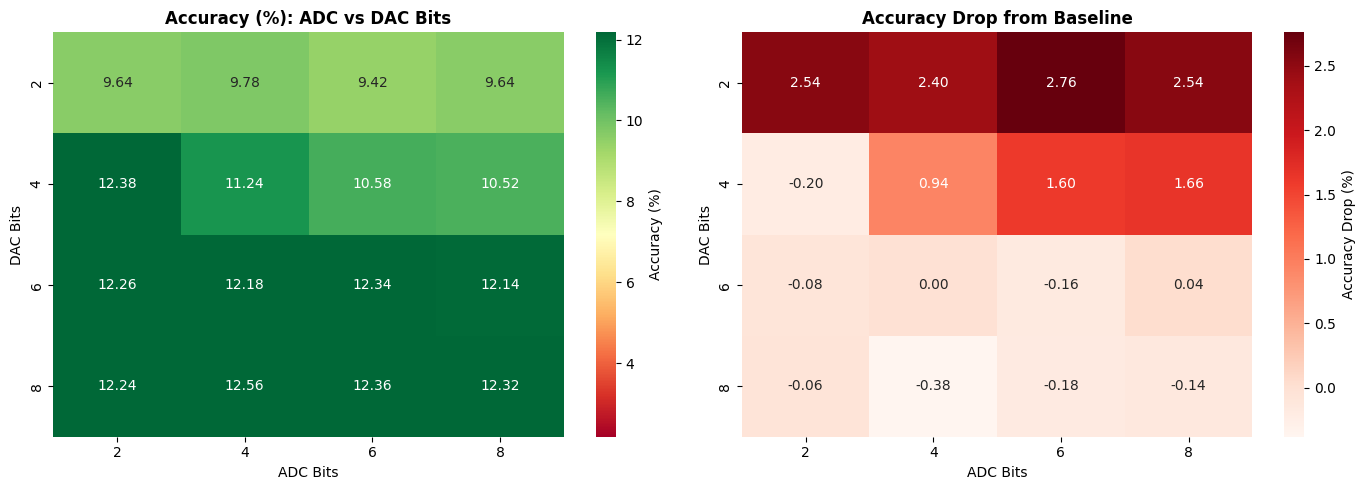

In [15]:
# Create ADC/DAC accuracy heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reshape for heatmap
acc_matrix = adc_dac_df.pivot_table(
    index='DAC_bits',
    columns='ADC_bits',
    values='Accuracy'
)

drop_matrix = adc_dac_df.pivot_table(
    index='DAC_bits',
    columns='ADC_bits',
    values='Accuracy_Drop'
)

# Plot 1: Absolute accuracy
sns.heatmap(
    acc_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=baseline_acc-10,
    vmax=baseline_acc,
    ax=axes[0],
    cbar_kws={'label': 'Accuracy (%)'}
)
axes[0].set_title('Accuracy (%): ADC vs DAC Bits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ADC Bits')
axes[0].set_ylabel('DAC Bits')

# Plot 2: Accuracy drop
sns.heatmap(
    drop_matrix,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    ax=axes[1],
    cbar_kws={'label': 'Accuracy Drop (%)'}
)
axes[1].set_title('Accuracy Drop from Baseline', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ADC Bits')
axes[1].set_ylabel('DAC Bits')

plt.tight_layout()
plt.savefig('adc_dac_sweep.png', dpi=300, bbox_inches='tight')
print("✅ Saved: adc_dac_sweep.png")
plt.show()

✅ Saved: drift_analysis.png


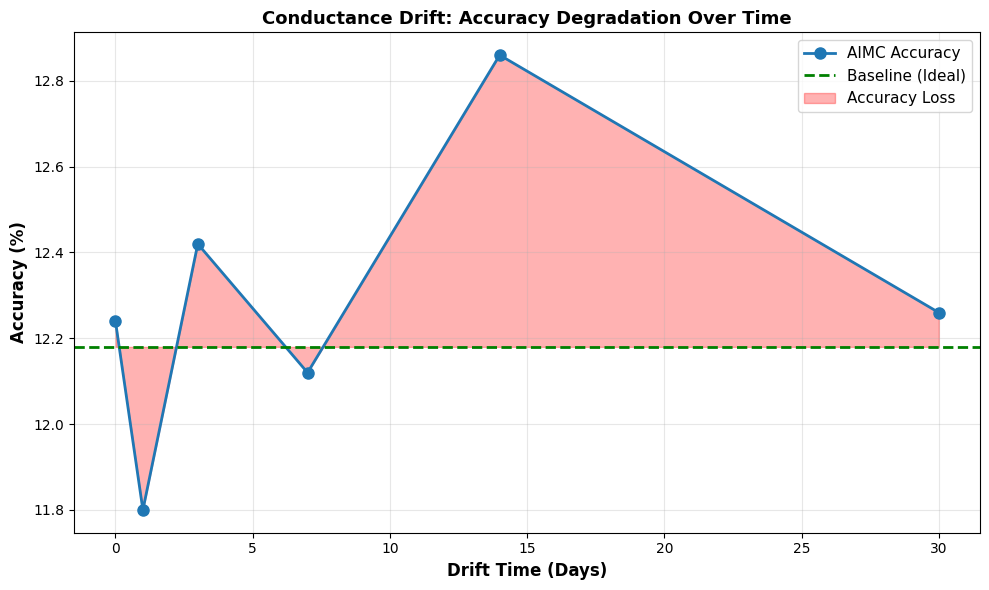

In [16]:
# Create drift vs accuracy plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    drift_df['Drift_Days'],
    drift_df['Accuracy'],
    marker='o',
    markersize=8,
    linewidth=2,
    label='AIMC Accuracy',
    color='#1f77b4'
)

ax.axhline(
    y=baseline_acc,
    color='green',
    linestyle='--',
    linewidth=2,
    label='Baseline (Ideal)'
)

ax.fill_between(
    drift_df['Drift_Days'],
    drift_df['Accuracy'],
    baseline_acc,
    alpha=0.3,
    color='red',
    label='Accuracy Loss'
)

ax.set_xlabel('Drift Time (Days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Conductance Drift: Accuracy Degradation Over Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('drift_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: drift_analysis.png")
plt.show()

✅ Saved: device_model_comparison.png


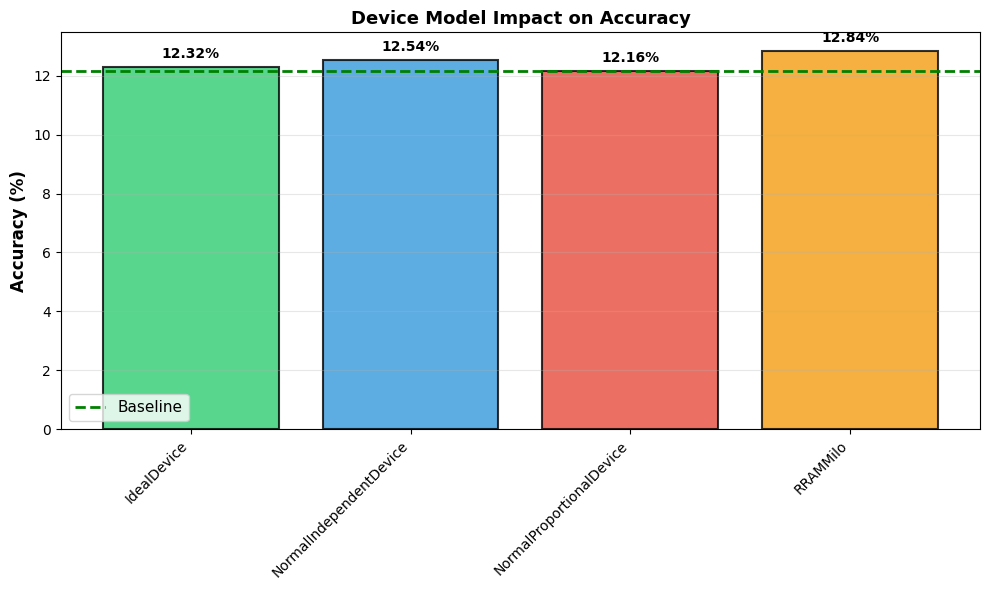

In [17]:
# Device model comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = ax.bar(
    range(len(device_model_df)),
    device_model_df['Accuracy'],
    color=colors,
    alpha=0.8,
    edgecolor='black',
    linewidth=1.5
)

ax.axhline(
    y=baseline_acc,
    color='green',
    linestyle='--',
    linewidth=2,
    label='Baseline'
)

ax.set_xticks(range(len(device_model_df)))
ax.set_xticklabels(device_model_df['Device_Model'], rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Device Model Impact on Accuracy', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, device_model_df['Accuracy'])):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.2,
        f'{acc:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('device_model_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: device_model_comparison.png")
plt.show()

In [18]:
print("\n" + "=" * 70)
print("AIMC SIMULATION SUMMARY")
print("=" * 70)

print(f"\nModel: {MODEL_NAME.upper()}")
print(f"Dataset: {DATASET_NAME}")
print(f"Test Samples: {EVAL_SIZE}")
print(f"\nBaseline Accuracy (Ideal): {baseline_acc:.2f}%")

print("\n" + "-" * 70)
print("ADC/DAC SWEEP")
print("-" * 70)
print(f"ADC Bits Tested: {ADC_BITS_LIST}")
print(f"DAC Bits Tested: {DAC_BITS_LIST}")
print(f"Best Accuracy: {adc_dac_df['Accuracy'].max():.2f}%")
print(f"Worst Accuracy: {adc_dac_df['Accuracy'].min():.2f}%")
print(f"Average Accuracy Drop: {adc_dac_df['Accuracy_Drop'].mean():.2f}%")

print("\n" + "-" * 70)
print("DRIFT ANALYSIS")
print("-" * 70)
print(f"Drift Times (days): {DRIFT_TIMES}")
print(f"Day 0 Accuracy: {drift_df[drift_df['Drift_Days']==0]['Accuracy'].values[0]:.2f}%")
print(f"Day 30 Accuracy: {drift_df[drift_df['Drift_Days']==30]['Accuracy'].values[0]:.2f}%")
print(f"Total Drift Impact: {drift_df[drift_df['Drift_Days']==0]['Accuracy'].values[0] - drift_df[drift_df['Drift_Days']==30]['Accuracy'].values[0]:.2f}%")

print("\n" + "-" * 70)
print("DEVICE MODELS")
print("-" * 70)
for _, row in device_model_df.iterrows():
    print(f"{row['Device_Model']:30s}: {row['Accuracy']:6.2f}% (Δ={row['Accuracy_Drop']:+.2f}%)")

print("\n" + "=" * 70)
print("✅ AIMC Evaluation Complete!")
print("=" * 70)


AIMC SIMULATION SUMMARY

Model: INCEPTION_V3
Dataset: CIFAR-10
Test Samples: 5000

Baseline Accuracy (Ideal): 12.18%

----------------------------------------------------------------------
ADC/DAC SWEEP
----------------------------------------------------------------------
ADC Bits Tested: [2, 4, 6, 8]
DAC Bits Tested: [2, 4, 6, 8]
Best Accuracy: 12.56%
Worst Accuracy: 9.42%
Average Accuracy Drop: 0.83%

----------------------------------------------------------------------
DRIFT ANALYSIS
----------------------------------------------------------------------
Drift Times (days): [0, 1, 3, 7, 14, 30]
Day 0 Accuracy: 12.24%
Day 30 Accuracy: 12.26%
Total Drift Impact: -0.02%

----------------------------------------------------------------------
DEVICE MODELS
----------------------------------------------------------------------
IdealDevice                   :  12.32% (Δ=-0.14%)
NormalIndependentDevice       :  12.54% (Δ=-0.36%)
NormalProportionalDevice      :  12.16% (Δ=+0.02%)
RRAMMilo 

In [19]:
# Export results for publication
adc_dac_df.to_csv('results_adc_dac_sweep.csv', index=False)
drift_df.to_csv('results_drift_analysis.csv', index=False)
device_model_df.to_csv('results_device_models.csv', index=False)

print("✅ Results exported:")
print("   - results_adc_dac_sweep.csv")
print("   - results_drift_analysis.csv")
print("   - results_device_models.csv")

✅ Results exported:
   - results_adc_dac_sweep.csv
   - results_drift_analysis.csv
   - results_device_models.csv
